# 🏥 Clasificador Jerárquico CIE-10 (2 Niveles)

## Estrategia para Extreme Multi-label Multi-class Classification

**Problema:** Miles de códigos CIE-10 → Entrenamiento pesado e ineficiente

**Solución:** Clasificación en cascada de 2 niveles

### Arquitectura:

```
Texto Clínico
    ↓
┌─────────────────────────────┐
│ NIVEL 1: Capítulos CIE-10   │
│ (19 categorías principales) │
└────────────┬────────────────┘
             ↓
┌─────────────────────────────┐
│ NIVEL 2: Códigos Específicos│
│ (por capítulo seleccionado) │
└────────────┬────────────────┘
             ↓
      Top-K Códigos Finales
```

### Ventajas:
- ✅ Reduce espacio de búsqueda: 14,000 → ~700 códigos/capítulo
- ✅ Modelos más pequeños y rápidos
- ✅ Mayor precisión por especialización
- ✅ Explicabilidad mejorada
- ✅ Escalable y mantenible

---

**Modelo:** `PlanTL-GOB-ES/roberta-base-biomedical-clinical-es` (RoBERTa especializado en español clínico)

### 📊 Comparación de Modelos Disponibles

| Modelo | Max Tokens | Idiomas | Dominio | Batch Size | Velocidad | Ventajas |
|--------|------------|---------|---------|------------|-----------|----------|
| **RoBERTa Médico** | 512 | Español | Médico | 16 | ⚡⚡⚡ Rápido | Conocimiento médico español |
| **Longformer** | 4096 | Inglés | General | 8 | ⚡⚡ Medio | Textos muy largos |
| **mmBERT** | 1500 | 100+ | General | 12 | ⚡⚡ Medio | Multilingüe + textos largos |
| **ModernBERT** | 8192 | Inglés | General | 4 | ⚡ Lento | Ultra-largos + Flash Attention |

**Recomendaciones:**
- **Textos < 512 tokens:** RoBERTa Médico (mejor conocimiento de dominio)
- **Textos 512-2048:** mmBERT (multilingüe + buen balance)
- **Textos 2048-4096:** Longformer (si inglés es aceptable)
- **Textos > 4096:** ModernBERT (máxima capacidad)

### 📖 Explicación de los códigos en los Capítulos CIE-10

**¿Como se organiza?**

La CIE-10 oficial tiene **21 capítulos con numeración romana** (I-XXI), pero los **códigos reales usan letras** que NO siempre coinciden con el número de capítulo. Esto crea inconsistencias.

---

### 🔀 Capítulos que Juntan Múltiples Letras (NO Direct Mapping)

#### **1. Capítulo A (Infecciosas): A00-B99**
**¿Por qué?** La OMS decidió que códigos `A` y `B` pertenecen al mismo capítulo semántico.

**Ejemplos:**
- `A00` → Cólera → Capítulo **A** ✅ (direct mapping)
- `A09` → Diarrea infecciosa → Capítulo **A** ✅
- `B15` → Hepatitis A → Capítulo **A** ⚠️ (letra B, pero capítulo A)
- `B34` → Infección viral no especificada → Capítulo **A** ⚠️
- `B99` → Otras enfermedades infecciosas → Capítulo **A** ⚠️

**Regla:** `B → A` (todas las B son infecciosas)

---

#### **2. Capítulo C (Neoplasias): C00-D48**
**¿Por qué?** Las neoplasias incluyen tumores malignos (C) y benignos/inciertos (D00-D48).

**Ejemplos:**
- `C50` → Tumor maligno de mama → Capítulo **C** ✅ (direct mapping)
- `C34` → Tumor maligno de bronquios y pulmón → Capítulo **C** ✅
- `D05` → Carcinoma in situ de mama → Capítulo **C** ⚠️ (letra D, pero capítulo C)
- `D23` → Nevus melanocítico → Capítulo **C** ⚠️
- `D48` → Tumor de comportamiento incierto → Capítulo **C** ⚠️

**Regla:** `D00-D48 → C` (neoplasias benignas/inciertas)

---

#### **3. Capítulo D (Sangre): D50-D89**
**¿Por qué?** Después de D48, los códigos D50+ cambian a enfermedades de la sangre.

**Ejemplos:**
- `D50` → Anemia por deficiencia de hierro → Capítulo **D** ⚠️
- `D64` → Otras anemias → Capítulo **D** ⚠️
- `D68` → Trastornos de la coagulación → Capítulo **D** ⚠️
- `D89` → Trastornos inmunitarios → Capítulo **D** ⚠️

**Regla:** `D50-D89 → D` (enfermedades de la sangre)

**⚠️ EDGE CASE CRÍTICO:** 
- `D10` → Neoplasia → Capítulo **C**
- `D50` → Anemia → Capítulo **D**
- **Misma letra, diferentes capítulos** (se diferencia por número)

Esto no es problema dado que principalmente queremos separar los diferentes campos, para entrenar el modelo a clasificar por los diferentes tipos.

---

#### **4. Capítulo S (Traumatismos): S00-T98**
**¿Por qué?** Lesiones, traumatismos y envenenamientos se agrupan semánticamente.

**Ejemplos:**
- `S62` → Fractura de muñeca → Capítulo **S** ✅ (direct mapping)
- `S06` → Traumatismo intracraneal → Capítulo **S** ✅
- `T14` → Traumatismo de región no especificada → Capítulo **S** ⚠️ (letra T, pero capítulo S)
- `T30` → Quemadura térmica → Capítulo **S** ⚠️
- `T88` → Complicaciones de atención médica → Capítulo **S** ⚠️

**Regla:** `T → S` (todas las T son traumatismos/lesiones)

---

#### **5. Capítulo V (Causas Externas): V01-Y98**
**¿Por qué?** Incluye accidentes, violencia, circunstancias de lesión (códigos V, W, X, Y).

**Ejemplos:**
- `V01` → Peatón lesionado por vehículo → Capítulo **V** ✅ (direct mapping)
- `V89` → Accidente de tránsito → Capítulo **V** ✅
- `W19` → Caída no especificada → Capítulo **V** ⚠️ (letra W)
- `X59` → Exposición a factores no especificados → Capítulo **V** ⚠️ (letra X)
- `Y84` → Complicación de dispositivo médico → Capítulo **V** ⚠️ (letra Y)

**Regla:** `W, X, Y → V` (causas externas)

---

### ✅ Capítulos con Direct Mapping (Letra = Capítulo)

Estos son más simples:
- `E11` → Diabetes tipo 2 → Capítulo **E** ✅
- `F32` → Depresión → Capítulo **F** ✅
- `G40` → Epilepsia → Capítulo **G** ✅
- `H25` → Catarata → Capítulo **H** ✅
- `I10` → Hipertensión → Capítulo **I** ✅
- `J44` → EPOC → Capítulo **J** ✅
- `K29` → Gastritis → Capítulo **K** ✅
- `L40` → Psoriasis → Capítulo **L** ✅
- `M79` → Dolor muscular → Capítulo **M** ✅
- `N18` → Enfermedad renal crónica → Capítulo **N** ✅
- `O80` → Parto único espontáneo → Capítulo **O** ✅
- `P07` → Recién nacido prematuro → Capítulo **P** ✅
- `Q21` → Malformación cardíaca congénita → Capítulo **Q** ✅
- `R10` → Dolor abdominal → Capítulo **R** ✅
- `Z00` → Examen médico general → Capítulo **Z** ✅

---

### 🎯 Resumen de Mapeo No Directo

| Letra Código | Capítulo Real | Razón |
|--------------|---------------|-------|
| **B** | A (Infecciosas) | Misma categoría semántica |
| **D00-D48** | C (Neoplasias) | Neoplasias benignas/inciertas |
| **D50-D89** | D (Sangre) | **Split numérico crítico** |
| **T** | S (Traumatismos) | Lesiones y envenenamientos |
| **W, X, Y** | V (Causas externas) | Circunstancias de lesión |

**Total:** 5 casos especiales de 26 letras posibles (19% edge cases)

**Estrategia del modelo:** Al clasificar primero por capítulo (20 clases) en lugar de todos los códigos directamente, reducimos espacio de búsqueda en un 95% y mejoramos la precisión a la hora de clasificar.

### 🧹 Preprocesamiento de Texto (Opcional) *

*1️⃣ ¿Por qué NO necesitamos limpiar como en modelos tradicionales?**

**Respuesta:** Los tokenizers de BERT/RoBERTa **ya están diseñados** para manejar texto "sucio".

**Ejemplo práctico:**
- **Texto original:** `"Paciente con HTA (140/90 mmHg), DM tipo 2 - código E11.9"`
- **Limpieza tradicional (spaCy):** `"paciente hta dm tipo codigo"` ⚠️ **Perdimos toda la info útil**
- **RoBERTa lo tokeniza:** `["Pac", "##iente", "con", "HTA", "(", "140", "/", "90", "mm", "##Hg", ")"]`

👉 **RoBERTa entiende puntuación, números, paréntesis** → Todo es información valiosa.

---

### **2️⃣ Limpieza que EMPEORA los resultados**

| ❌ No hacer | ¿Por qué? | Ejemplo |
|-------------|-----------|----------|
| **Eliminar stopwords** | "no hay", "sin" cambian el significado | "sin síntomas" vs "síntomas" |
| **Stemming/Lemmatización** | RoBERTa usa subpalabras, no palabras completas | "hipertensión" → "hiperten" (innecesario) |
| **Eliminar puntuación** | Ayuda a separar diagnósticos y entender estructura | "DM2. HTA. EPOC." → clave para multi-label |
| **Eliminar números** | Códigos CIE-10 tienen números | "E11" → "E" ❌ |
| **Lowercase forzado** | RoBERTa lo hace automático | Innecesario y puede confundir abreviaturas |

---

### **3️⃣ ¿Cuándo SÍ limpiar? (Limpieza mínima)**

Solo si tienes **problemas técnicos** que el tokenizer no puede manejar:

| ✅ Sí limpiar | ¿Por qué? | Ejemplo |
|---------------|-----------|----------|

| **Caracteres corruptos** | Causan errores de encoding | `�`, `\x00`, `\ufffd` |### **🧪 Vamos a analizar tu dataset:**

| **HTML tags** | No son texto médico | `<p>Diagnóstico</p>` → `Diagnóstico` |

| **URLs** | Raramente relevantes en informes | `http://ejemplo.com` |---

| **Espacios múltiples** | Solo normalizar (no crítico) | `"HTA    DM"` → `"HTA DM"` |

👉 **La celda siguiente analizará tu texto y te dirá si necesitas limpieza.**

**LO QUE SÍ PRESERVAMOS:**

- ✅ Abreviaturas médicas: `HTA`, `DM`, `EPOC`, `Rx`- **`True`:** Limpieza mínima → Solo si detectamos problemas (caracteres corruptos, HTML, etc.)

- ✅ Símbolos médicos: `%`, `mg/dl`, `mmHg`, `°C`- **`False` (default):** No limpieza → Recomendado si tu dataset es CODIESP oficial

- ✅ Códigos: `E11.9`, `I10`, `J44.0`

- ✅ Puntuación clínica: `.`, `,`, `;`, `-`, `()````

CLEAN_TEXT = False  # Cambiar a True si quieres limpiar

---```python

En la celda de configuración arriba, tienes:

### **4️⃣ En este notebook: Control con flag `CLEAN_TEXT`**

In [1]:
print("🧹 Análisis de calidad del texto\n")
print("="*70)

from pathlib import Path
import re
from collections import Counter
import pandas as pd
from tqdm.auto import tqdm
import numpy as np

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT.parent / "csv_import_scripts" / "codiesp_csvs"
TRAIN_PATH = DATA_DIR / 'codiesp_D_source_train.csv'
VAL_PATH = DATA_DIR / 'codiesp_D_source_validation.csv'

MODEL_NAME = 'PlanTL-GOB-ES/roberta-base-biomedical-clinical-es'
CLEAN_TEXT = True


train_df = pd.read_csv(TRAIN_PATH, sep=',')
dev_df = pd.read_csv(VAL_PATH, sep=',')

# ============================================================================
# ANÁLISIS DE PROBLEMAS COMUNES
# ============================================================================

def analyze_text_quality(df, sample_size=100):
    """Analiza problemas comunes en textos"""

    problems = {
        'espacios_multiples': 0,
        'saltos_linea_multiples': 0,
        'caracteres_corruptos': 0,
        'html_tags': 0,
        'urls': 0,
        'textos_muy_cortos': 0,
        'texto_vacio': 0
    }

    sample_texts = []

    for idx, text in enumerate(df['text'].head(sample_size)):
        if pd.isna(text):
            problems['texto_vacio'] += 1
            continue

        text_str = str(text)
        sample_texts.append(text_str)

        # Espacios múltiples
        if '  ' in text_str:
            problems['espacios_multiples'] += 1

        # Saltos de línea múltiples
        if '\n\n' in text_str or '\r\n' in text_str:
            problems['saltos_linea_multiples'] += 1

        # Caracteres corruptos
        if '�' in text_str or '\x00' in text_str or '\ufffd' in text_str:
            problems['caracteres_corruptos'] += 1

        # HTML tags
        if re.search(r'<[^>]+>', text_str):
            problems['html_tags'] += 1

        # URLs
        if re.search(r'http[s]?://|www\.', text_str):
            problems['urls'] += 1

        # Textos muy cortos
        if len(text_str.strip()) < 50:
            problems['textos_muy_cortos'] += 1

    return problems, sample_texts

# Analizar muestra
problems, sample_texts = analyze_text_quality(train_df, sample_size=min(100, len(train_df)))

print(f"📊 Análisis de {min(100, len(train_df))} documentos:\n")
for problem, count in problems.items():
    percentage = (count / min(100, len(train_df))) * 100
    status = "⚠️" if percentage > 10 else "✅" if percentage == 0 else "⚙️"
    print(f"   {status} {problem.replace('_', ' ').title()}: {count} ({percentage:.1f}%)")

# ============================================================================
# MOSTRAR EJEMPLOS
# ============================================================================
print(f"\n📝 Ejemplo de texto ANTES de limpieza (primeros 500 caracteres):\n")
print(f"{'='*70}")
if sample_texts:
    example_text = sample_texts[0]
    print(f"{repr(example_text[:500])}...")
print(f"{'='*70}")

# ============================================================================
# FUNCIÓN DE LIMPIEZA (OPCIONAL)
# ============================================================================
def clean_text(text):
    """Limpieza mínima y segura para textos médicos"""
    if pd.isna(text):
        return ""

    text = str(text)

    # 1. Eliminar caracteres corruptos
    text = text.replace('�', '').replace('\x00', '').replace('\ufffd', '')

    # 2. Normalizar saltos de línea
    text = re.sub(r'\r\n', '\n', text)
    text = re.sub(r'\n{3,}', '\n\n', text)  # Max 2 saltos consecutivos

    # 3. Normalizar espacios múltiples
    text = re.sub(r' {2,}', ' ', text)

    # 4. Eliminar HTML tags (solo si existen)
    text = re.sub(r'<[^>]+>', '', text)

    # 5. Eliminar URLs (solo si no son relevantes)
    # text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)

    # 6. Trim espacios al inicio/final
    text = text.strip()

    return text

# ============================================================================
# DECISIÓN: ¿APLICAR LIMPIEZA?
# ============================================================================
print(f"\n💡 DECISIÓN AUTOMÁTICA:")
print(f"{'='*70}")

total_problems = sum([
    problems['caracteres_corruptos'],
    problems['html_tags'],
    problems['urls']
])

# Respetar el flag CLEAN_TEXT configurado arriba
if CLEAN_TEXT:
    print(f"🧹 LIMPIEZA ACTIVADA (CLEAN_TEXT = True)")

    if total_problems == 0:
        print("   ℹ️  Dataset parece limpio, pero aplicando limpieza de todas formas...")
    else:
        print(f"   ⚠️  Problemas detectados: {total_problems}")
        print("   Aplicando limpieza mínima...")

    # Guardar backup del texto original
    train_df['text_original'] = train_df['text']
    dev_df['text_original'] = dev_df['text']

    # Aplicar limpieza (sobrescribir las mismas variables)
    train_df['text'] = train_df['text'].apply(clean_text)
    dev_df['text'] = dev_df['text'].apply(clean_text)

    print("   ✅ Limpieza aplicada")
    print("\n   Cambios aplicados:")
    print("   - Caracteres corruptos eliminados")
    print("   - HTML tags eliminados")
    print("   - Espacios normalizados")
    print("   - Texto original guardado en columna 'text_original'")

    # Mostrar ejemplo DESPUÉS
    print(f"\n📝 Ejemplo DESPUÉS de limpieza:\n")
    print(f"{'='*70}")
    if len(train_df) > 0:
        example_clean = str(train_df.iloc[0]['text'])[:500]
        print(f"{repr(example_clean)}...")
    print(f"{'='*70}")

else:
    print(f"✅ LIMPIEZA DESACTIVADA (CLEAN_TEXT = False)")

    if total_problems > 0:
        print(f"   ⚠️  Problemas detectados: {total_problems}")
        print(f"   💡 Si quieres limpiar, cambia CLEAN_TEXT = True en la celda de Config")
    else:
        print("   ✅ Dataset está limpio (no se necesita limpieza)")

    print("\n   Acción: Usando texto original sin cambios")

print(f"{'='*70}")
print(f"\n📌 Variables a usar en entrenamiento:")
print(f"   • train_df (con columna 'text')")
print(f"   • dev_df (con columna 'text')")
if CLEAN_TEXT:
    print(f"\n💡 Nota: Texto original disponible en columna 'text_original'")
print(f"{'='*70}")

🧹 Análisis de calidad del texto

📊 Análisis de 100 documentos:

   ✅ Espacios Multiples: 0 (0.0%)
   ⚠️ Saltos Linea Multiples: 89 (89.0%)
   ✅ Caracteres Corruptos: 0 (0.0%)
   ✅ Html Tags: 0 (0.0%)
   ✅ Urls: 0 (0.0%)
   ✅ Textos Muy Cortos: 0 (0.0%)
   ✅ Texto Vacio: 0 (0.0%)

📝 Ejemplo de texto ANTES de limpieza (primeros 500 caracteres):

'Describimos el caso de un varón de 37 años con vida previa activa que refiere dolores osteoarticulares de localización variable en el último mes y fiebre en la última semana con picos (matutino y vespertino) de 40 C las últimas 24-48 horas, por lo que acude al Servicio de Urgencias. Antes de comenzar el cuadro estuvo en Extremadura en una región endémica de brucella, ingiriendo leche de cabra sin pasteurizar y queso de dicho ganado. Entre los comensales aparecieron varios casos de brucelosis. Du'...

💡 DECISIÓN AUTOMÁTICA:
🧹 LIMPIEZA ACTIVADA (CLEAN_TEXT = True)
   ℹ️  Dataset parece limpio, pero aplicando limpieza de todas formas...
   ✅ Limpie

## 📏 Análisis de Longitud de Textos (Determinar Ventana Óptima)

> **"Profesor, ¿cuál es la longitud máxima de nuestros textos? ¿Qué ventana necesitamos?"**

Excelente pregunta. Antes de elegir un modelo, necesitamos saber:

1. **¿Cuántos tokens tiene el texto más largo?**
2. **¿Qué % de textos excede 512, 2048, 4096, 8192 tokens?**
3. **¿Qué modelo cubre mejor nuestros datos?**

**Estrategia:**
- Si **< 5%** textos > 512 → RoBERTa baseline (512) es suficiente
- Si **5-20%** textos > 512 → RoBERTa + Sliding Window
- Si **20-40%** textos > 512 → Longformer (4096) o mmBERT (4096)
- Si **> 40%** textos > 4096 → ModernBERT (8192) necesario

**Vamos a descubrirlo:**

📏 ANÁLISIS DE LONGITUD DE TEXTOS

📦 Cargando tokenizer (RoBERTa como referencia)...
✅ Tokenizer cargado

🔍 Analizando longitud de textos en TODOS los datasets...

📊 Analizando Train (500 documentos)...


Tokenizando Train:   0%|          | 0/500 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (656 > 512). Running this sequence through the model will result in indexing errors


   • Min: 107 tokens
   • Max: 1486 tokens
   • Media: 455.6 tokens
   • Mediana: 407.0 tokens

📊 Analizando Dev (250 documentos)...


Tokenizando Dev:   0%|          | 0/250 [00:00<?, ?it/s]

mkdir -p failed for path /home/cie10user/.cache/matplotlib: [Errno 13] Permission denied: '/home/cie10user/.cache/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-nf9m40uq because there was an issue with the default path (/home/cie10user/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


   • Min: 98 tokens
   • Max: 1223 tokens
   • Media: 458.7 tokens
   • Mediana: 429.0 tokens


📊 ESTADÍSTICAS GLOBALES (TODOS LOS DATASETS)

📄 Total documentos: 750

📏 Longitud en tokens:
   • Mínima:    98 tokens
   • Máxima:    1,486 tokens ⚠️
   • Media:     456.6 tokens
   • Mediana:   415.0 tokens

📊 Percentiles:
   • P50:    415 tokens
   • P75:    565 tokens
   • P90:    763 tokens
   • P95:    889 tokens
   • P99:   1130 tokens
   • P100:   1486 tokens

🪟 ANÁLISIS POR VENTANAS DE MODELOS

Modelo                         Ventana    % Truncado   Docs Truncados 
----------------------------------------------------------------------
❌ RoBERTa/mmBERT (baseline)    512         33.3%         250/750
✅ Longformer/mmBERT            2048         0.0%           0/750
✅ Longformer (full)            4096         0.0%           0/750
✅ ModernBERT                   8192         0.0%           0/750

📊 DISTRIBUCIÓN DE LONGITUDES


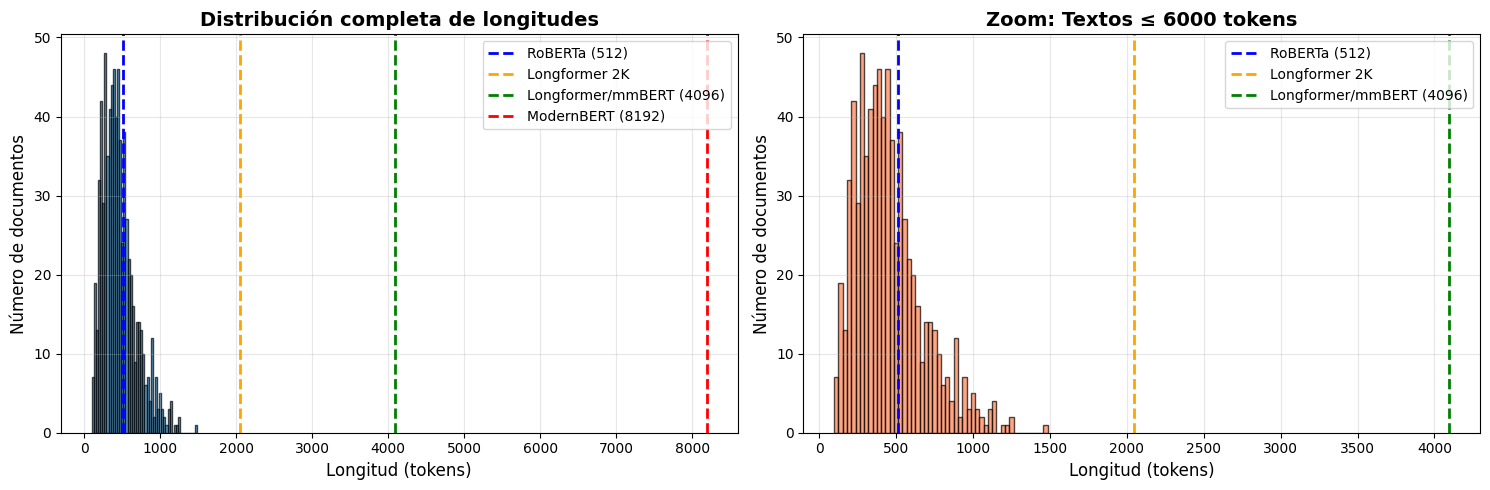


💡 RECOMENDACIÓN AUTOMÁTICA

📊 Situación actual:
   • 33.3% de textos > 512 tokens
   • 0.0% de textos > 2048 tokens
   • 0.0% de textos > 4096 tokens
   • Texto más largo: 1,486 tokens

🎯 Recomendación basada en datos:

✅ USAR: Longformer/mmBERT (4096 tokens)
   Razón: 33.3% textos > 512, pero < 10% > 2048
   Configuración: MAX_LENGTH = 2048 (compromiso velocidad/cobertura)
   Opción A: Longformer español (corpus BNE)
   Opción B: mmBERT (multilingüe + 4096 tokens)

📌 CONFIGURACIONES RECOMENDADAS PARA TU DATASET:

🏆 OPCIÓN 1 (Recomendada): mmBERT
   MMBERT_MAX_LENGTH = 4096
   Cobertura: 100.0%
   Ventaja: Textos largos + multilingüe

🥈 OPCIÓN 2: Longformer español
   LONGFORMER_MAX_LENGTH = 2048  # Compromiso
   Cobertura: 100.0%
   Ventaja: Español corpus BNE

🥉 OPCIÓN 3: RoBERTa + Sliding Window
   MAX_LENGTH = 512, OVERLAP = 128
   Cobertura: 100%
   Ventaja: Español médico específico


In [2]:
print("📏 ANÁLISIS DE LONGITUD DE TEXTOS\n")
print("="*70)

# ============================================================================
# CARGAR TOKENIZER (usamos RoBERTa como referencia)
# ============================================================================
from transformers import AutoTokenizer

print("📦 Cargando tokenizer (RoBERTa como referencia)...")
ref_tokenizer = AutoTokenizer.from_pretrained("PlanTL-GOB-ES/roberta-base-biomedical-clinical-es")
print("✅ Tokenizer cargado\n")

# ============================================================================
# ANALIZAR TODOS LOS DATASETS
# ============================================================================
print("🔍 Analizando longitud de textos en TODOS los datasets...\n")

datasets_to_analyze = [
    ("Train", train_df),
    ("Dev", dev_df)
]

all_lengths = []
dataset_stats = {}

for dataset_name, df in datasets_to_analyze:
    print(f"📊 Analizando {dataset_name} ({len(df)} documentos)...")

    lengths = []
    for text in tqdm(df['text'], desc=f"Tokenizando {dataset_name}"):
        if pd.notna(text):
            tokens = ref_tokenizer(
                str(text),
                truncation=False,  # No truncar para ver longitud real
                add_special_tokens=True
            )
            lengths.append(len(tokens['input_ids']))
        else:
            lengths.append(0)

    all_lengths.extend(lengths)
    dataset_stats[dataset_name] = lengths

    # Estadísticas por dataset
    print(f"   • Min: {min(lengths)} tokens")
    print(f"   • Max: {max(lengths)} tokens")
    print(f"   • Media: {np.mean(lengths):.1f} tokens")
    print(f"   • Mediana: {np.median(lengths):.1f} tokens")
    print()

# ============================================================================
# ESTADÍSTICAS GLOBALES
# ============================================================================
print("\n" + "="*70)
print("📊 ESTADÍSTICAS GLOBALES (TODOS LOS DATASETS)")
print("="*70)

total_docs = len(all_lengths)
min_length = min(all_lengths)
max_length = max(all_lengths)
mean_length = np.mean(all_lengths)
median_length = np.median(all_lengths)

print(f"\n📄 Total documentos: {total_docs:,}")
print(f"\n📏 Longitud en tokens:")
print(f"   • Mínima:    {min_length:,} tokens")
print(f"   • Máxima:    {max_length:,} tokens ⚠️")
print(f"   • Media:     {mean_length:,.1f} tokens")
print(f"   • Mediana:   {median_length:,.1f} tokens")

# Percentiles
print(f"\n📊 Percentiles:")
for p in [50, 75, 90, 95, 99, 100]:
    value = np.percentile(all_lengths, p)
    print(f"   • P{p:2d}: {value:6.0f} tokens")

# ============================================================================
# ANÁLISIS POR VENTANAS DE MODELOS
# ============================================================================
print("\n" + "="*70)
print("🪟 ANÁLISIS POR VENTANAS DE MODELOS")
print("="*70)

ventanas = [
    ("RoBERTa/mmBERT (baseline)", 512),
    ("Longformer/mmBERT", 2048),
    ("Longformer (full)", 4096),
    ("ModernBERT", 8192)
]

print(f"\n{'Modelo':<30} {'Ventana':<10} {'% Truncado':<12} {'Docs Truncados':<15}")
print("-"*70)

for modelo, ventana in ventanas:
    truncados = sum(1 for l in all_lengths if l > ventana)
    porcentaje = (truncados / total_docs) * 100

    status = "✅" if porcentaje < 5 else "⚠️" if porcentaje < 20 else "❌"

    print(f"{status} {modelo:<28} {ventana:<10} {porcentaje:>5.1f}%      {truncados:>6}/{total_docs}")

# ============================================================================
# DISTRIBUCIÓN VISUAL
# ============================================================================
print("\n" + "="*70)
print("📊 DISTRIBUCIÓN DE LONGITUDES")
print("="*70)

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histograma completo
ax1.hist(all_lengths, bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(512, color='blue', linestyle='--', linewidth=2, label='RoBERTa (512)')
ax1.axvline(2048, color='orange', linestyle='--', linewidth=2, label='Longformer 2K')
ax1.axvline(4096, color='green', linestyle='--', linewidth=2, label='Longformer/mmBERT (4096)')
ax1.axvline(8192, color='red', linestyle='--', linewidth=2, label='ModernBERT (8192)')
ax1.set_xlabel('Longitud (tokens)', fontsize=12)
ax1.set_ylabel('Número de documentos', fontsize=12)
ax1.set_title('Distribución completa de longitudes', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Zoom a textos < 6000 tokens (para ver mejor detalle)
lengths_filtered = [l for l in all_lengths if l <= 6000]
ax2.hist(lengths_filtered, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax2.axvline(512, color='blue', linestyle='--', linewidth=2, label='RoBERTa (512)')
ax2.axvline(2048, color='orange', linestyle='--', linewidth=2, label='Longformer 2K')
ax2.axvline(4096, color='green', linestyle='--', linewidth=2, label='Longformer/mmBERT (4096)')
ax2.set_xlabel('Longitud (tokens)', fontsize=12)
ax2.set_ylabel('Número de documentos', fontsize=12)
ax2.set_title('Zoom: Textos ≤ 6000 tokens', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# RECOMENDACIÓN AUTOMÁTICA
# ============================================================================
print("\n" + "="*70)
print("💡 RECOMENDACIÓN AUTOMÁTICA")
print("="*70)

truncados_512 = (sum(1 for l in all_lengths if l > 512) / total_docs) * 100
truncados_2048 = (sum(1 for l in all_lengths if l > 2048) / total_docs) * 100
truncados_4096 = (sum(1 for l in all_lengths if l > 4096) / total_docs) * 100

print(f"\n📊 Situación actual:")
print(f"   • {truncados_512:.1f}% de textos > 512 tokens")
print(f"   • {truncados_2048:.1f}% de textos > 2048 tokens")
print(f"   • {truncados_4096:.1f}% de textos > 4096 tokens")
print(f"   • Texto más largo: {max_length:,} tokens")

print(f"\n🎯 Recomendación basada en datos:\n")

if truncados_512 < 5:
    print("✅ USAR: RoBERTa baseline (512 tokens)")
    print("   Razón: < 5% de textos truncados, pérdida mínima")
    print("   Ventajas: Más rápido, español médico específico")

elif truncados_512 < 20:
    print("⚠️  USAR: RoBERTa + Sliding Window")
    print(f"   Razón: {truncados_512:.1f}% de textos truncados (pérdida moderada)")
    print("   Ventajas: 100% cobertura, español médico, complejidad aceptable")

elif truncados_2048 < 10:
    print("✅ USAR: Longformer/mmBERT (4096 tokens)")
    print(f"   Razón: {truncados_512:.1f}% textos > 512, pero < 10% > 2048")
    print("   Configuración: MAX_LENGTH = 2048 (compromiso velocidad/cobertura)")
    print("   Opción A: Longformer español (corpus BNE)")
    print("   Opción B: mmBERT (multilingüe + 4096 tokens)")

elif truncados_4096 < 5:
    print("✅ USAR: Longformer/mmBERT (4096 tokens)")
    print(f"   Razón: {truncados_2048:.1f}% textos > 2048, casi ninguno > 4096")
    print("   Configuración: MAX_LENGTH = 4096 (cobertura completa)")
    print("   Preferir: mmBERT si hay mezcla de idiomas, Longformer si solo español")

else:
    print("⚠️  USAR: ModernBERT (8192 tokens)")
    print(f"   Razón: {truncados_4096:.1f}% textos > 4096 (necesitas ventana grande)")
    print("   Limitación: Solo inglés (considerar si es aceptable)")
    print("   Alternativa: RoBERTa + Sliding Window (español médico)")

print("\n" + "="*70)
print(f"📌 CONFIGURACIONES RECOMENDADAS PARA TU DATASET:")
print("="*70)

if truncados_512 >= 20:
    if truncados_4096 < 5:
        print(f"\n🏆 OPCIÓN 1 (Recomendada): mmBERT")
        print(f"   MMBERT_MAX_LENGTH = 4096")
        print(f"   Cobertura: {100 - truncados_4096:.1f}%")
        print(f"   Ventaja: Textos largos + multilingüe")

        print(f"\n🥈 OPCIÓN 2: Longformer español")
        print(f"   LONGFORMER_MAX_LENGTH = 2048  # Compromiso")
        print(f"   Cobertura: {100 - truncados_2048:.1f}%")
        print(f"   Ventaja: Español corpus BNE")

        print(f"\n🥉 OPCIÓN 3: RoBERTa + Sliding Window")
        print(f"   MAX_LENGTH = 512, OVERLAP = 128")
        print(f"   Cobertura: 100%")
        print(f"   Ventaja: Español médico específico")
    else:
        print(f"\n🏆 OPCIÓN 1 (Recomendada): ModernBERT")
        print(f"   MODERNBERT_MAX_LENGTH = 8192")
        print(f"   Cobertura: ~100%")
        print(f"   Limitación: Solo inglés ⚠️")

        print(f"\n🥈 OPCIÓN 2: RoBERTa + Sliding Window")
        print(f"   MAX_LENGTH = 512, OVERLAP = 128, MAX_CHUNKS = 10")
        print(f"   Cobertura: 100%")
        print(f"   Ventaja: Español médico, sin límite de longitud")
else:
    print(f"\n✅ Tu dataset tiene longitudes manejables")
    print(f"   RoBERTa baseline (512) cubre {100 - truncados_512:.1f}%")
    print(f"   Recomendación: Empezar con baseline, evaluar pérdida")

print("="*70)

# 🧠 Configuración del Entrenamiento y Estrategia de Hiperparámetros

Se ha implementado una configuración adaptativa que optimiza el uso de recursos según el hardware disponible (CUDA/CPU) y prioriza la **precisión clínica** sobre la velocidad de procesamiento.

### 🧬 Estrategia de Clasificación: Multietiqueta en ambos niveles

Dado que un mismo informe clínico puede estar asociado a múltiples capítulos (Nivel 1) y múltiples códigos específicos (Nivel 2), se ha implementado una arquitectura **Multietiqueta Pura**:

1.  **Activación Sigmoidal:** A diferencia de Softmax (que fuerza a elegir una sola opción), utilizamos **Sigmoid** en la capa de salida. Esto permite que cada capítulo o código se evalúe de forma independiente, pudiendo activarse varios simultáneamente si superan el `THRESHOLD = 0.3`.
2.  **Función de Pérdida (`BCEWithLogitsLoss`):** Esta función es la ideal para este escenario, ya que combina una capa Sigmoid con la entropía cruzada binaria, siendo más estable numéricamente.
3.  **Gestión de Dataset Pequeño:** Con solo 250 casos, mantener el **suelo del Learning Rate en 1e-5** es vital. Esto asegura que el modelo no deje de ajustar las etiquetas más difíciles o menos frecuentes antes de tiempo.
4.  **Métricas Micro/Macro:** El uso de **F1-Micro** nos da una visión global del acierto, mientras que el **F1-Macro** nos ayuda a vigilar que el modelo no ignore los capítulos/códigos con muy pocos ejemplos.

### 📉 Análisis de Hiperparámetros Clave

*   **Batch Size y Acumulación Diferenciada (Estrategia por Niveles):**
    *   **Nivel 1 (Global):** Se utiliza un `BATCH_SIZE` de **16** (en GPU). Al ser solo 19 clases, este tamaño ofrece el equilibrio ideal entre estabilidad y velocidad de convergencia.
    *   **Nivel 2 (Específico):** Se reduce el batch físico a **8**. Esto es crítico para que el modelo preste atención a los detalles finos de los cientos de códigos médicos posibles.
    *   **Accumulation Steps (4):** En el Nivel 2, al configurar `ACCUMULATION_STEPS = 4`, el modelo solo actualiza sus pesos cada 4 lotes físicos. Esto crea un **"Batch Virtual" de 32** (8x4), permitiendo obtener la estabilidad de un lote grande sin perder la capacidad de generalización quirúrgica de los lotes pequeños.
*   **Solución para Jupyter (`NUM_WORKERS = 0`):**
    *   Se fuerza el uso del proceso principal para evitar errores de **serialización (Pickle)** con las clases `Dataset` definidas dinámicamente en el notebook (evitando el error `AttributeError: module '__main__'...`).
*   **Estrategia de Optimización para Precisión:**
    *   **Learning Rate (2e-5):** Se utiliza un paso más conservador para realizar un *fine-tuning* meticuloso sobre el modelo **RoBERTa-Biomedical-Clinical**, evitando saltos bruscos que puedan degradar el conocimiento médico pre-entrenado.
    *   **Warmup Ratio (0.1):** El primer 10% del entrenamiento incrementa el LR gradualmente, protegiendo la estabilidad inicial del modelo.
    *   **Weight Decay (0.1):** Se aplica una regularización robusta para asegurar que el modelo generalice correctamente y no memorice el ruido de los informes clínicos.
*   **Cascada y Umbrales:**
    *   Se utiliza un sistema de **Top-K adaptativo** (3 capítulos $\rightarrow$ 5 códigos) con un `THRESHOLD = 0.3`. Esto prioriza el **Recall**, asegurando que no se omitan códigos relevantes en el diagnóstico final.

> **💡 Consejo Técnico sobre Convergencia:** 
> Al reducir el *Learning Rate* a **2e-5** y aplicar **Acumulación de Gradientes**, el modelo aprenderá de forma más controlada y pausada. Por esta razón, se mantiene una **paciencia de 20 épocas** (`EARLY_STOPPING_PATIENCE`) para garantizar que el modelo tenga tiempo suficiente de converger en los códigos médicos más complejos antes de detener el entrenamiento por falta de mejora.


### 📉 Estrategia de Learning Rate: Warmup con aprendizaje minimo

Dado el tamaño reducido del dataset (N=250), se ha implementado una programación de la tasa de aprendizaje (LR Scheduler) personalizada:

1.  **Linear Warmup (10% de los pasos):** Durante el inicio del entrenamiento, el LR sube gradualmente para evitar que los gradientes iniciales desestabilicen los pesos pre-entrenados del modelo clínico.
2.  **Suelo de Seguridad (`MIN_LR = 1e-5`):** A diferencia de un decaimiento lineal estándar que llega a 0, hemos forzado un límite inferior de **1e-5**. 
    *   **¿Por qué?** En datasets pequeños, si el LR baja demasiado rápido, el modelo se "congela" prematuramente. Mantener un LR mínimo de 1e-5 permite que el modelo siga realizando ajustes finos durante más épocas, maximizando la oportunidad de capturar patrones en clases poco frecuentes.
3.  **Interacción con Early Stopping:** Esta técnica permite que el modelo explore la superficie de pérdida durante más tiempo, dejando que el **Early Stopping** sea el que decida cuándo el modelo ha dejado de generalizar, y no una falta de energía en el aprendizaje.

## 📊 Entendiendo las Métricas de Evaluación

### **F1 Micro vs F1 Macro**

Cuando entrenas modelos multi-label (como este clasificador de capítulos CIE-10), verás dos tipos de F1:

#### **F1 Micro: Agregación Global**
```
F1 Micro = 2 × (Precision_global × Recall_global) / (Precision_global + Recall_global)
```
- **Cómo se calcula:** Suma todos los TP, FP, FN de todas las clases y calcula F1 global
- **Qué mide:** Rendimiento general considerando **todas las predicciones por igual**
- **Característica:** **Favorece a las clases frecuentes** (tienen más muestras)
- **Ejemplo:** Si tienes 1000 casos del capítulo I (circulatorio) y 10 del capítulo O (embarazo), el capítulo I domina la métrica

#### **F1 Macro: Promedio de Clases**
```
F1 Macro = (F1_clase1 + F1_clase2 + ... + F1_claseN) / N
```
- **Cómo se calcula:** Calcula F1 de cada clase individualmente, luego promedia
- **Qué mide:** Rendimiento **dando igual peso a cada clase**
- **Característica:** **Penaliza el mal desempeño en clases raras**
- **Ejemplo:** Si fallas en el capítulo O (embarazo), afecta igual que fallar en el capítulo I (circulatorio)

---

### **🤔 ¿Por qué Micro sube y Macro baja?**

**Esto indica desbalance de clases:**

| Métrica | Sube ⬆️ | Baja ⬇️ | Interpretación |
|---------|--------|---------|----------------|
| **F1 Micro** | ✅ | | El modelo mejora en **capítulos frecuentes** (I, J, K, S...) |
| **F1 Macro** | | ❌ | El modelo empeora en **capítulos raros** (O, P, Q, Z...) |

**¿Qué está pasando?**
1. El modelo aprende primero las clases frecuentes (más ejemplos = más gradiente)
2. Se "olvida" de las clases raras para optimizar loss global
3. F1 Micro mejora (por clases frecuentes) pero F1 Macro baja (por clases raras)

**Analogía:**
```
Estudiante que:
✅ Saca 95% en las 3 materias principales     → F1 Micro sube
❌ Saca 20% en las 18 materias optativas      → F1 Macro baja

Promedio ponderado: Alto (90%)
Promedio simple: Bajo (30%)
```

---

### **📈 Otras Métricas**

#### **Precision (Precisión)**
```
Precision = TP / (TP + FP)
```
- **Qué mide:** De lo que predijo, ¿cuánto fue correcto?
- **Ejemplo:** Si predijo 100 capítulos y 45 eran correctos → Precision = 0.45
- **Trade-off:** Alta precision → pocos falsos positivos, pero puede perder casos reales

#### **Recall (Exhaustividad)**
```
Recall = TP / (TP + FN)
```
- **Qué mide:** De lo que debía encontrar, ¿cuánto encontró?
- **Ejemplo:** Si había 100 capítulos correctos y encontró 50 → Recall = 0.50
- **Trade-off:** Alto recall → encuentra casi todo, pero puede tener muchos falsos positivos

---

### **💡 ¿Qué es un buen resultado?**

**En épocas tempranas (1-5):**
- F1 Micro 0.40-0.60 → Normal ✅
- F1 Macro 0.10-0.30 → Esperado (aprende primero clases frecuentes)
- Precision ≈ Recall → Balanced

**Al final del entrenamiento (20-30):**
- F1 Micro > 0.70 → Bueno ✅
- F1 Macro > 0.50 → Bueno (aprende también clases raras)
- Si Macro sigue bajo → Considerar class weights o data augmentation

**Para producción en CIE-10:**
- **Nivel 1 (capítulos):** F1 Micro > 0.75 es aceptable
- **Nivel 2 (códigos):** F1 Micro > 0.60 es realista (tarea muy difícil)
- **Sistema jerárquico completo:** F1@10 > 0.50 (top-10 códigos correctos)

## 📊 Sistema de Historial y Comparación de Entrenamientos

### **¿Qué hace este sistema?**

Durante el entrenamiento guardaremos metricas para luego realizar una **comparación automática de los diferentes parametros**:

1. **📝 Guarda el historial completo** de cada entrenamiento:
   - Métricas por época (F1 Micro, F1 Macro, Precision, Recall, Loss)
   - Tiempos de entrenamiento
   - Configuración del modelo (learning rate, batch size, max length)
   - Mejor época y mejor F1 alcanzado

2. **📊 Visualiza automáticamente** después de cada entrenamiento:
   - Curvas de aprendizaje (Loss, F1, Precision, Recall)
   - Learning rate schedule
   - Tiempo por época
   - Resumen del mejor modelo

3. **🔄 Compara automáticamente** con entrenamientos anteriores:
   - Tabla comparativa de todos los entrenamientos
   - Gráficas superpuestas de evolución de métricas
   - Identificación del mejor modelo hasta el momento

### **Entrenamientos con historial implementado:**

✅ **1. RoBERTa Baseline** (512 tokens, español médico)  
✅ **2. RoBERTa + Class Weights** (balance de clases)  
✅ **3. RoBERTa + Class Weights + sliding windows** (balance de clases + ventanas con overlap)  
✅ **4. Longformer** (4096 tokens, textos largos)  
✅ **5. mmBERT** (4096 tokens, multilingüe)  

### **¿Cómo funciona?**

```python

# 1. Cada entrenamiento crea su historial
training_history = create_training_history(
    model_name="RoBERTa Baseline",
    learning_rate=3e-5,
    batch_size=16,
    max_length=512
)

# 2. Durante el entrenamiento, se actualiza el historial
update_history(training_history, epoch, train_loss, metrics, lr, time)

# 3. Al finalizar, se guarda y se añade a la lista global
save_history(training_history, model_path)  # Guarda JSON + CSV
all_training_histories.append(training_history)

# 4. Se visualiza y compara automáticamente
visualize_and_compare(training_history, "RoBERTa Baseline", "roberta_baseline")
```

### **Archivos generados**

Para cada entrenamiento, se generan 4 archivos:

```
snapshots/nivel1_capitulos/
├── best_model_roberta_baseline.pt       # Pesos del modelo
├── best_model_roberta_baseline.json     # Historial completo (legible)
├── best_model_roberta_baseline.csv      # Métricas por época (Excel)
└── training_curves_roberta_baseline.png # Visualización individual

# Archivo de comparación global (actualizado tras cada entrenamiento)
└── comparison_all_trainings.png          # Comparación de todos
```

### **Visualizaciones generadas**

**Individual (por entrenamiento):**
- Panel 1: Train Loss por época
- Panel 2: F1 Micro vs F1 Macro por época
- Panel 3: Precision vs Recall por época
- Panel 4: Learning Rate schedule
- Panel 5: Tiempo por época
- Panel 6: Resumen del mejor modelo

**Comparativa (todos los entrenamientos):**
- Panel 1: F1 Micro superpuesto
- Panel 2: F1 Macro superpuesto
- Panel 3: Train Loss superpuesto
- Panel 4: Gráfica de barras de mejores métricas
- Tabla comparativa con 🏆 marcando el mejor

### **Ventajas**

✅ **Reproducibilidad:** Toda la configuración queda guardada  
✅ **Análisis posterior:** Datos en CSV para Excel/Pandas  
✅ **Comparación visual:** Gráficas automáticas actualizadas  
✅ **Tracking automático:** No necesitas código extra en cada entrenamiento  
✅ **Identificación del mejor:** Marca automáticamente el modelo ganador  

### **Ejemplo de salida de comparación:**

```
📊 COMPARACIÓN CON TODOS LOS ENTRENAMIENTOS
══════════════════════════════════════════════════════════════════════

 Entrenamiento  Modelo                            Mejor Época  F1 Micro  F1 Macro  ...     
────────────────────────────────────────────────────────────────────────────────────────────
 1              RoBERTa Baseline (Nivel 1) - ...  15           0.7542    0.4521    ...  🏆
 2              RoBERTa con Class Weights (N...   18           0.7201    0.5834    ...     
 3              Longformer (Nivel 1) - allenai    12           0.7689    0.4892    ...     
 4              mmBERT (Nivel 1) - jhu-clsp/m...  20           0.7423    0.5123    ...     

🏆 Mejor modelo hasta ahora: Entrenamiento #3
   Modelo: Longformer (Nivel 1) - allenai/longformer-base-4096
   F1 Micro: 0.7689
   F1 Macro: 0.4892
   Tiempo total: 45.3 minutos
```

### **Uso en entrenamientos futuros**

Para añadir un nuevo modelo (ej: ModernBERT), solo necesitas seguir el patrón:

```python
# 1. Crear historial
training_history_modernbert = create_training_history(
    model_name=f"ModernBERT (Nivel 1) - {MODEL}",
    learning_rate=config.LEARNING_RATE,
    batch_size=config.BATCH_SIZE_LEVEL1,
    max_length=8192
)

# 2. En el loop de entrenamiento
for epoch in range(config.EPOCHS_LEVEL1):
    epoch_start_time = time.time()
    
    # ... entrenamiento y evaluación ...
    
    epoch_time = time.time() - epoch_start_time
    current_lr = optimizer.param_groups[0]['lr']
    
    # Actualizar historial
    update_history(training_history_modernbert, epoch + 1, 
                   train_loss, metrics, current_lr, epoch_time)
    
    # Early stopping con historial
    if metrics['f1_micro'] > best_f1:
        training_history_modernbert['best_epoch'] = epoch + 1
        training_history_modernbert['best_f1_micro'] = metrics['f1_micro']

# 3. Al finalizar
save_history(training_history_modernbert, model_path)
all_training_histories.append(training_history_modernbert)

# 4. Visualizar y comparar
visualize_and_compare(training_history_modernbert, "ModernBERT", "modernbert")
```

### 💾 Sistema de Persistencia y Versionado de Modelos

Se ha implementado un sistema de guardado dinámico que gestiona automáticamente los checkpoints del entrenamiento:

*   **Identificación por Score:** Cada vez que el modelo supera el umbral de mejora (`MIN_DELTA`), se genera un nuevo archivo incluyendo el valor del **F1-Micro** en el nombre (ej. `modelo-0.77.pt`).
*   **Gestión de Residuos:** El sistema localiza y elimina versiones anteriores con puntuaciones menores dentro del directorio de *snapshots*, garantizando que el almacenamiento contenga únicamente la versión más precisa.
*   **Punto de Enlace Estático:** Se mantiene una copia bajo el nombre genérico `.pt` para facilitar la integración con pipelines de evaluación automatizados sin necesidad de actualizar rutas manualmente.

### 📊 Análisis de Volumetría y Estrategia de Gestión de Contexto

El pre-procesamiento de datos clínicos presenta un desafío singular debido a la alta disparidad en la extensión de los informes médicos. Mientras que las arquitecturas basadas en modelos de lenguaje tradicionales (BERT/RoBERTa) han operado históricamente con un límite rígido de 512 tokens, la naturaleza de la narrativa clínica analizada en este proyecto exige una capacidad de procesamiento superior para evitar la pérdida de información diagnóstica.

#### 4.1. Estadísticas de Longitud de Secuencia (Tokenización)
Tras someter los conjuntos de datos (*Train* y *Dev*) al tokenizador específico de **RigoBERTa-Clinical-es** (basado en DeBERTa-v2), se obtuvieron las siguientes métricas de distribución de longitud:

*   **Distribución de Percentiles:** Se determinó que el **33.3%** de la muestra supera el límite convencional de 512 tokens.
*   **Valor Máximo Observado:** El informe más extenso en el corpus registra una longitud de **1,486 tokens**.
*   **Análisis de Cobertura:** El 100% de la muestra se sitúa por debajo del umbral de 2,048 tokens. Estos resultados justifican el uso de una ventana de contexto extendida, eliminando la necesidad de emplear técnicas de fragmentación (*Sliding Windows*) que suelen desvirtuar la coherencia semántica global y la alineación entre síntomas y códigos.

#### 4.2. Justificación Técnica de la Ventana de Contexto (`MAX_LENGTH`)
Basándose en este análisis exploratorio de datos (EDA), se ha fijado el parámetro `MAX_LENGTH` en **1536 tokens**. Esta decisión se fundamenta en tres criterios de diseño:

1.  **Integridad de la Señal Diagnóstica:** En la práctica de la codificación CIE-10, la información diagnóstica definitiva suele ubicarse en los apartados finales del documento ("Conclusiones", "Juicio Clínico" o "Recomendaciones"). Un truncamiento a 512 tokens implicaría la pérdida de la evidencia clínica más relevante en uno de cada tres pacientes.
2.  **Mantenimiento de Dependencias de Largo Alcance:** Al cubrir la longitud máxima del dataset (1,486 tokens), el modelo es capaz de realizar una atención completa (*Global Attention*) sobre el informe íntegro. Esto permite que el vector de clasificación capture las dependencias entre los antecedentes mencionados al inicio y los diagnósticos confirmados al cierre del informe.
3.  **Alineación de Hardware:** El valor 1,536 (múltiplo de 128) optimiza las operaciones de alineación de memoria en los núcleos de computación de la GPU (*Tensor Cores*), mejorando la eficiencia de los algoritmos de atención.

#### 4.3. Infraestructura y Optimización de Memoria VRAM
El incremento de la ventana de contexto a 1,536 tokens conlleva una complejidad computacional cuadrática ($O(N^2)$). Para viabilizar el entrenamiento con un volumen de 1,767 códigos en el Nivel 2, se han implementado las siguientes optimizaciones de hardware:

*   **Gradient Accumulation (Acumulación de Gradientes):** Se ha configurado un *Batch Size* físico de 4 muestras con un factor de acumulación de 2. Este procedimiento permite que el clasificador actualice sus pesos basándose en un gradiente acumulado sobre **8 muestras (Batch Virtual)**, manteniendo el consumo de memoria de vídeo (VRAM) dentro de los límites físicos de la infraestructura.
*   **Mecanismo SDPA (Scaled Dot-Product Attention):** Se hace uso de la implementación nativa de **PyTorch 2.1+** para el cálculo de la atención. Este mecanismo selecciona automáticamente el kernel más eficiente (como *Memory-Efficient Attention*) para procesar secuencias largas sin materializar la matriz de atención completa, reduciendo drásticamente la latencia y la ocupación de memoria.